In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f4 
function_folder = os.path.join(base_dir, "function_4")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f4 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 4: shape = {df_f4.shape}, columns = {df_f4.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']


In [3]:
week1_results = {"f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305)}

In [4]:
week2_results = {"f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795)}

In [5]:
week3_results = {"f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579)}

In [6]:
week4_results = {"f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084)}

In [7]:
week5_results = {"f4": ([0.342113, 0.430851, 0.327587, 0.458906], -0.49820890718197175)}

In [8]:
week6_results = {"f4": ([0.378009, 0.410452, 0.389136, 0.370426], 0.34655132659709453)}

In [9]:
week7_results = {"f4": ([0.402435, 0.485938, 0.405691, 0.380615], -1.5762466920468117)}

In [10]:
week8_results = {"f4": ([0.413226, 0.408926, 0.383757, 0.471737], -0.9393775297880427)}

In [11]:
week9_results = {"f4": ([0.378009, 0.230452, 0.389136, 0.550426], -4.6298356823203015)}

In [12]:
week10_results = {"f4": ([0.393437, 0.413310, 0.349543, 0.408827], 0.5545122853059294)}

In [13]:
week11_results = {"f4": ([0.400800, 0.416211, 0.324678, 0.408967], -0.02563374723946721)}

In [14]:
week12_results = {"f4": ([0.384050, 0.396528, 0.336384, 0.398087], -0.03859446180511794)}

In [15]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
    "week12": week12_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f4

for week, results in weekly_results.items():
    
    if "f4" not in results:
        continue
    
    inputs, output = results["f4"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f4
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "y1"]
    )
    
    # append to df_f4
    df_f4 = pd.concat([df_f4, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f4 = df_f4.drop_duplicates(ignore_index=True)

print("updated f4 shape:", df_f4.shape)


updated f4 shape: (42, 5)


In [16]:
print(df_f4)

          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.387488  0.804532  0.75

In [17]:
display(df_f4.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,42.0,0.502727,0.256847,0.037825,0.343325,0.402670,0.720481,0.985622
X2,42.0,0.452356,0.265538,0.006250,0.241946,0.439909,0.648051,0.919592
X3,42.0,0.438976,0.225141,0.042186,0.325405,0.389136,0.537084,0.939178
X4,42.0,0.462222,0.248009,0.081517,0.262212,0.442639,0.597817,0.999483
y1,42.0,-12.571751,9.611415,-32.625660,-17.625808,-12.940553,-2.537697,0.554512


## Feature vs y scatter plots


Feature vs y1 for f4


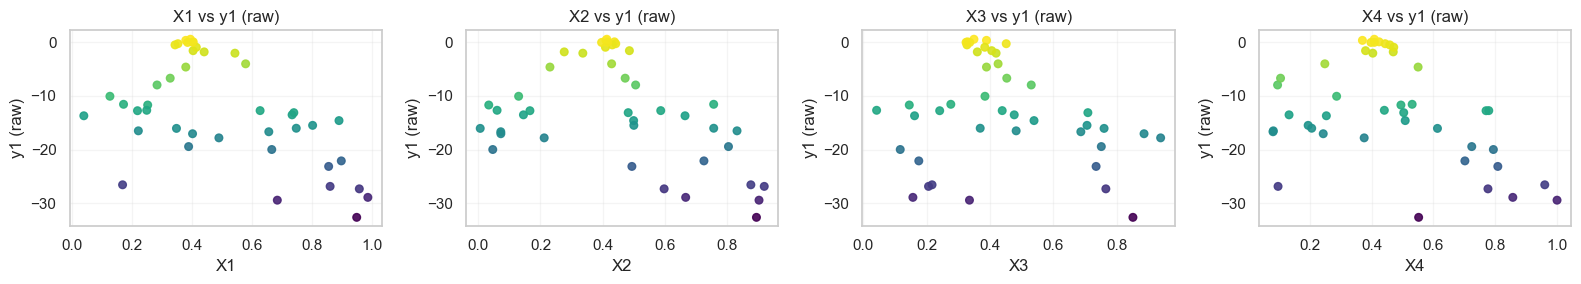

In [18]:
print("\nFeature vs y1 for f4")

# extract inputs and output for f4
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
X_f4 = df_f4[input_cols_f4].values
y_f4 = df_f4["y1"].values

# number of input features
n_features = X_f4.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# robust flattening
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f4):
    ax = axes[j]
    sc = ax.scatter(
        X_f4[:, j],
        y_f4,
        c=y_f4,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Correlation Analysis

df_f4: Consolidated Correlation Analysis
Agreement = Pearson and Spearman similar in sign and magnitude.
Nonlinear monotonic structure = Spearman >> Pearson or sign mismatch.

feature   pearson  spearman   kendall  pearson_spearman_diff status
     X1 -0.521141 -0.447956 -0.297502               0.073185  agree
     X2 -0.403892 -0.401021 -0.270616               0.002871  agree
     X3 -0.201842 -0.179571 -0.181290               0.022271  agree
     X4 -0.394823 -0.328580 -0.235772               0.066244  agree


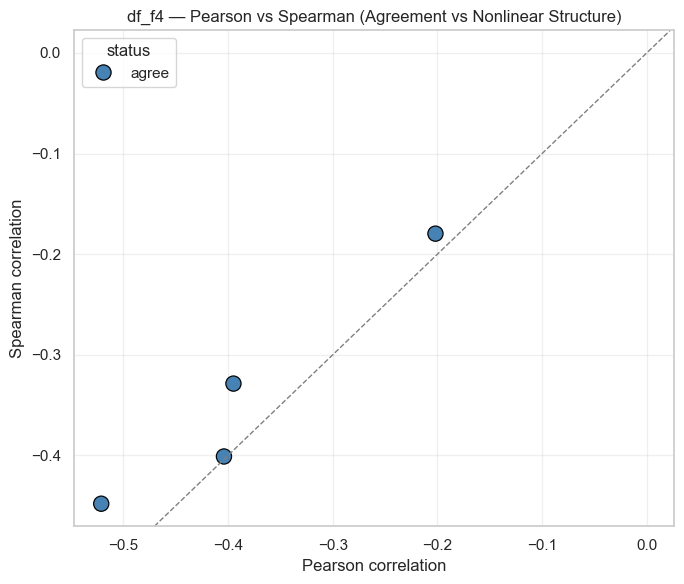

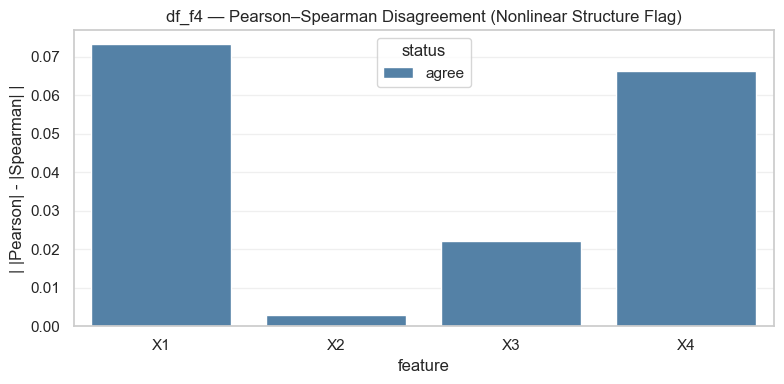

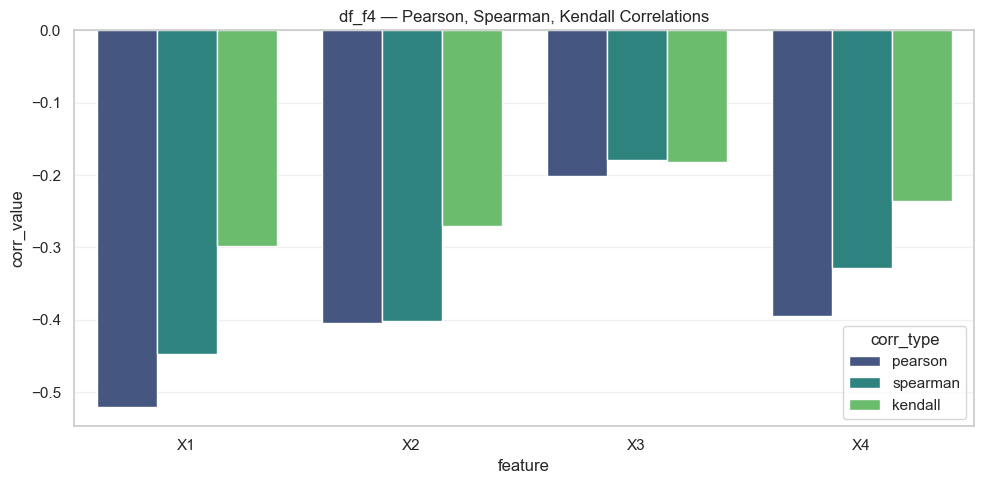

In [19]:
from scipy.stats import pearsonr, spearmanr, kendalltau


# Consolidated correlation analysis for df_f4
def consolidated_correlation(df_f4, y_col="y1", threshold=0.15):
    """
    Consolidated Pearson–Spearman–Kendall correlation analysis for df_f4,
    with diagnostics and visuals.
    """

    # Extract inputs and output
    input_cols = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols]
    y = df_f4[y_col].values

    rows = []

    # Compute correlations
    for col in input_cols:
        x = df_f4[col].values

        pear, _ = pearsonr(x, y)
        spear, _ = spearmanr(x, y)
        kend, _ = kendalltau(x, y)

        sign_agree = np.sign(pear) == np.sign(spear)
        mag_diff = abs(abs(pear) - abs(spear))

        if sign_agree and mag_diff < threshold:
            status = "agree"
        else:
            status = "nonlinear monotonic structure"

        rows.append({
            "feature": col,
            "pearson": pear,
            "spearman": spear,
            "kendall": kend,
            "pearson_spearman_diff": mag_diff,
            "status": status
        })

    df_corr = pd.DataFrame(rows)


    # Print Table
    print("df_f4: Consolidated Correlation Analysis")
    print("Agreement = Pearson and Spearman similar in sign and magnitude.")
    print("Nonlinear monotonic structure = Spearman >> Pearson or sign mismatch.\n")
    print(df_corr.to_string(index=False))

    # Pearson vs Spearman scatter
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=df_corr,
        x="pearson",
        y="spearman",
        hue="status",
        palette={"agree": "steelblue", "nonlinear monotonic structure": "darkorange"},
        s=120,
        edgecolor="black"
    )
    plt.axline((0, 0), slope=1, color="gray", linestyle="--", linewidth=1)
    plt.title("df_f4 — Pearson vs Spearman (Agreement vs Nonlinear Structure)")
    plt.xlabel("Pearson correlation")
    plt.ylabel("Spearman correlation")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Nonlinear structure flag plot
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=df_corr,
        x="feature",
        y="pearson_spearman_diff",
        hue="status",
        palette={"agree": "steelblue", "nonlinear monotonic structure": "darkorange"}
    )
    plt.title("df_f4 — Pearson–Spearman Disagreement (Nonlinear Structure Flag)")
    plt.ylabel("| |Pearson| - |Spearman| |")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Per-feature correlation bars
    df_melt = df_corr.melt(
        id_vars=["feature"],
        value_vars=["pearson", "spearman", "kendall"],
        var_name="corr_type",
        value_name="corr_value"
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_melt,
        x="feature",
        y="corr_value",
        hue="corr_type",
        palette="viridis"
    )
    plt.title("df_f4 — Pearson, Spearman, Kendall Correlations")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_corr


corr_f4 = consolidated_correlation(df_f4)



## Mutual Information & Partial Correlation

In [20]:
!pip install pingouin
import pingouin as pg
from scipy.stats import t
from numpy.linalg import inv

In [21]:
print("f4 — Partial Correlation with Holm–Bonferroni Correction")

# copy raw f4
df_f4_raw = df_f4.copy()

# define inputs and output
input_cols_f4 = [c for c in df_f4_raw.columns if c.startswith("X")]
output_col_f4 = "y1"

# store results for correction
pcorr_results = []

# compute partial correlations for each X feature
for x in input_cols_f4:
    covars = [c for c in input_cols_f4 if c != x]  # all other X's as covariates
    
    pcorr_raw_f4 = pg.partial_corr(
        data=df_f4_raw,
        x=x,
        y=output_col_f4,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f4)
    
    # store for correction
    pcorr_results.append({
        "feature": x,
        "partial_corr": pcorr_raw_f4["r"].values[0],
        "p_value": pcorr_raw_f4["p-val"].values[0]
    })

# convert to dataframe
df_pcorr = pd.DataFrame(pcorr_results)

# sort by p-value for Holm–Bonferroni
df_pcorr = df_pcorr.sort_values("p_value").reset_index(drop=True)

m = len(df_pcorr)
holm_p = []

# Holm–Bonferroni adjusted p-values
for i, p in enumerate(df_pcorr["p_value"]):
    adj = (m - i) * p
    holm_p.append(min(adj, 1.0))

df_pcorr["holm_bonferroni_p"] = holm_p
df_pcorr["significant"] = df_pcorr["holm_bonferroni_p"] < 0.05

print("df_f4: Consolidated Partial Correlations with Holm–Bonferroni Correction")
display(df_pcorr)



f4 — Partial Correlation with Holm–Bonferroni Correction

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,42,-0.382447,"[-0.62, -0.08]",0.016269



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,42,-0.316507,"[-0.57, -0.0]",0.049638



Partial correlation for X3:


,n,r,CI95%,p-val
pearson,42,-0.190852,"[-0.48, 0.13]",0.244494



Partial correlation for X4:


,n,r,CI95%,p-val
pearson,42,-0.35446,"[-0.6, -0.04]",0.026827


df_f4: Consolidated Partial Correlations with Holm–Bonferroni Correction


,feature,partial_corr,p_value,holm_bonferroni_p,significant
0,X1,-0.382447,0.016269,0.065077,False
1,X4,-0.354460,0.026827,0.080481,False
2,X2,-0.316507,0.049638,0.099276,False
3,X3,-0.190852,0.244494,0.244494,False


In [22]:
from sklearn.feature_selection import mutual_info_regression


def mutual_information_f4(df_f4, pcorr_df, y_col="y1"):
    """
    Compute MI for df_f4 and integrate with partial correlations.
    MI is used only as a secondary confirmation signal.
    """

    # extract inputs and output
    input_cols = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols].values
    y = df_f4[y_col].values

    # compute MI
    mi_vals = mutual_info_regression(X, y, random_state=0)

    df_mi = pd.DataFrame({
        "feature": input_cols,
        "mutual_information": mi_vals
    })

    # merge with partial correlations
    df_merge = pcorr_df.merge(df_mi, on="feature")

    # agreement flag
    df_merge["mi_pcorr_agree"] = (
        np.sign(df_merge["partial_corr"]) == np.sign(df_merge["mutual_information"])
    )

    # interpretive label
    df_merge["interpretation"] = np.where(
        df_merge["significant"] & df_merge["mi_pcorr_agree"],
        "confirmed (PCorr + MI agree)",
        np.where(
            df_merge["significant"] & ~df_merge["mi_pcorr_agree"],
            "PCorr only (MI unreliable)",
            "inactive"
        )
    )

    print("df_f4: Mutual Information (Secondary Diagnostic)")
    print("MI is used only as a cross-check. Partial correlations dominate.\n")
    display(df_merge)

    return df_merge

# run after computing pcorr_f4
mi_f4 = mutual_information_f4(df_f4, df_pcorr)


df_f4: Mutual Information (Secondary Diagnostic)
MI is used only as a cross-check. Partial correlations dominate.



,feature,partial_corr,p_value,holm_bonferroni_p,significant,mutual_information,mi_pcorr_agree,interpretation
0,X1,-0.382447,0.016269,0.065077,False,0.511185,False,inactive
1,X4,-0.354460,0.026827,0.080481,False,0.565389,False,inactive
2,X2,-0.316507,0.049638,0.099276,False,0.511333,False,inactive
3,X3,-0.190852,0.244494,0.244494,False,0.400768,False,inactive


## Topological Data Analysis

In [23]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [24]:
def build_mapper_graph_f4(df_f4,
                          filter_vals,
                          n_intervals=6,
                          overlap_frac=0.35,
                          cluster_eps=0.25,
                          cluster_min_samples=2):

    # extract X-matrix from df_f4
    input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols_f4].values

    X = np.asarray(X)
    filter_vals = np.asarray(filter_vals)

    # compute interval boundaries
    fmin, fmax = filter_vals.min(), filter_vals.max()
    interval_length = (fmax - fmin) / n_intervals
    overlap = interval_length * overlap_frac

    intervals = []
    for i in range(n_intervals):
        start = fmin + i * interval_length - overlap
        end = fmin + (i + 1) * interval_length + overlap
        intervals.append((start, end))

    G = nx.Graph()
    node_id = 0
    interval_clusters = []

    # cluster inside each interval
    for (start, end) in intervals:
        mask = (filter_vals >= start) & (filter_vals <= end)
        idxs = np.where(mask)[0]

        if len(idxs) == 0:
            interval_clusters.append([])
            continue

        X_sub = X[idxs]

        labels = DBSCAN(eps=cluster_eps,
                        min_samples=cluster_min_samples).fit_predict(X_sub)
        unique_labels = set(labels)

        clusters = []
        for lab in unique_labels:
            if lab == -1:
                continue  # ignore noise

            cluster_indices = idxs[labels == lab]

            G.add_node(node_id,
                       indices=cluster_indices,
                       size=len(cluster_indices))
            clusters.append(node_id)
            node_id += 1

        interval_clusters.append(clusters)

    # build edges between adjacent intervals
    for i in range(len(interval_clusters) - 1):
        for a in interval_clusters[i]:
            for b in interval_clusters[i + 1]:
                A = set(G.nodes[a]["indices"])
                B = set(G.nodes[b]["indices"])
                if len(A & B) > 0:
                    G.add_edge(a, b)

    return G


Mapper for f4
  mapper diagnostics: nodes=25, edges=11, connected_components=14
  node size: mean=2.36, min=1, max=20
  top nodes by max y (node, size, mean_y, max_y):
    node 22: size=20, mean_y=-4.5144, max_y=0.5545
    node 17: size=3, mean_y=-10.3920, max_y=-6.7021
    node 11: size=4, mean_y=-11.8024, max_y=-10.0696
    node 24: size=2, mean_y=-12.6342, max_y=-11.5657
    node 19: size=2, mean_y=-12.6342, max_y=-11.5657


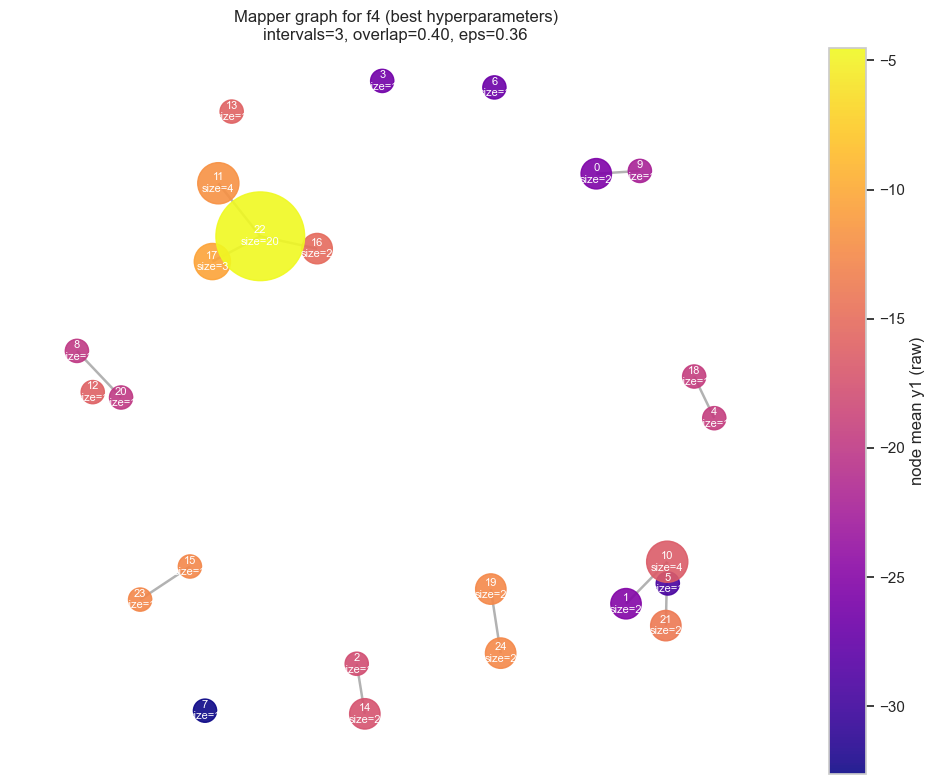

In [25]:
print("Mapper for f4")


# Prepare data
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = "y1"

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)

# filter = raw y1
filter_vals_f4 = y_f4.copy()


# Mapper graph with best hyperparameters
G_f4_best = build_mapper_graph_f4(
    df_f4=df_f4,
    filter_vals=filter_vals_f4,
    n_intervals=3,
    overlap_frac=0.40,
    cluster_eps=0.36,
    cluster_min_samples=1
)


# Diagnostics
n_nodes = G_f4_best.number_of_nodes()
n_edges = G_f4_best.number_of_edges()
n_components = nx.number_connected_components(G_f4_best)

print(f"  mapper diagnostics: nodes={n_nodes}, edges={n_edges}, connected_components={n_components}")

if n_nodes > 0:
    node_sizes = np.array([G_f4_best.nodes[n]["size"] for n in G_f4_best.nodes])
    print(f"  node size: mean={node_sizes.mean():.2f}, min={node_sizes.min():.0f}, max={node_sizes.max():.0f}")

    node_max_y = []
    node_mean_y = []

    for nkey in G_f4_best.nodes:
        idxs = G_f4_best.nodes[nkey]["indices"]
        node_max_y.append(float(filter_vals_f4[idxs].max()))
        node_mean_y.append(float(filter_vals_f4[idxs].mean()))

    node_max_y = np.array(node_max_y)
    node_mean_y = np.array(node_mean_y)

    # top 5 nodes by max y
    top_idx = np.argsort(node_max_y)[::-1][:5]
    print("  top nodes by max y (node, size, mean_y, max_y):")
    for t in top_idx:
        nkey = list(G_f4_best.nodes)[t]
        print(
            f"    node {nkey}: size={G_f4_best.nodes[nkey]['size']}, "
            f"mean_y={node_mean_y[t]:.4f}, max_y={node_max_y[t]:.4f}"
        )


# Visualization
if n_nodes > 0:
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G_f4_best, seed=0, k=0.4)

    node_colors = [
        np.mean(filter_vals_f4[G_f4_best.nodes[n]["indices"]])
        for n in G_f4_best.nodes
    ]

    node_sizes_plot = [
        80 + 200 * (G_f4_best.nodes[n]["size"])
        for n in G_f4_best.nodes
    ]

    nodes = nx.draw_networkx_nodes(
        G_f4_best,
        pos,
        node_color=node_colors,
        cmap="plasma",
        node_size=node_sizes_plot,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G_f4_best,
        pos,
        width=1.8,
        alpha=0.6,
        edge_color="gray"
    )

    labels = {
        n: f"{n}\nsize={G_f4_best.nodes[n]['size']}"
        for n in G_f4_best.nodes
    }

    nx.draw_networkx_labels(
        G_f4_best,
        pos,
        labels=labels,
        font_size=8,
        font_color="white"
    )

    plt.colorbar(nodes, label="node mean y1 (raw)")
    plt.title(
        "Mapper graph for f4 (best hyperparameters)\n"
        "intervals=3, overlap=0.40, eps=0.36"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Store results
results_f4_mapper_best = {
    "graph": G_f4_best,
    "filter_vals": filter_vals_f4,
    "input_cols": input_cols_f4,
    "output_col": output_col_f4,
    "best_params": {
        "intervals": 3,
        "overlap": 0.40,
        "eps": 0.36
    }
}


## K-means Clustering

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K-means clustering for f4


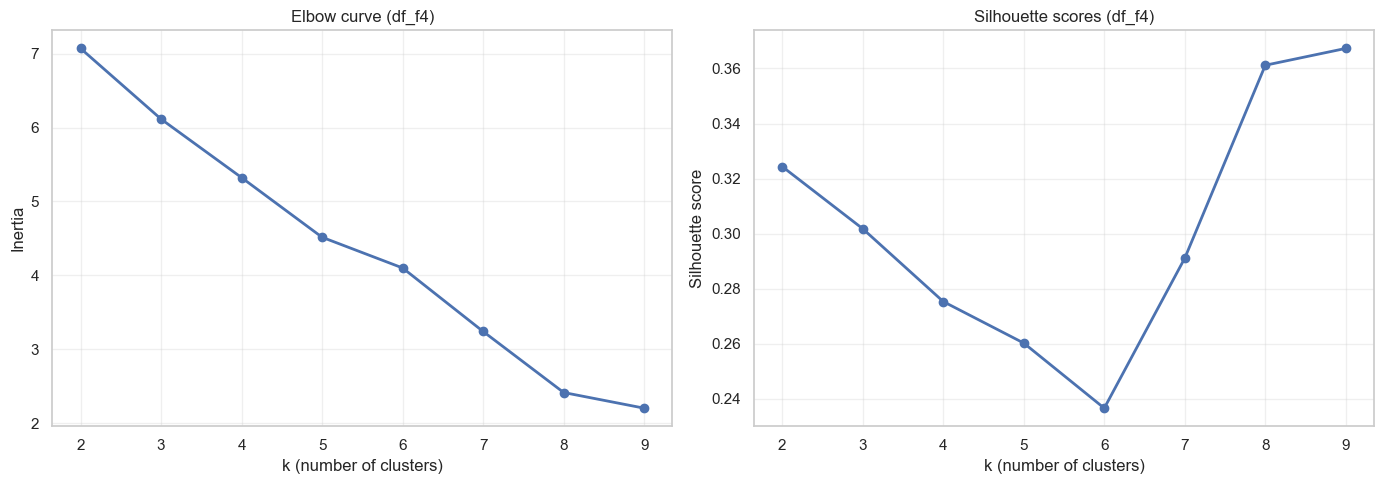

Best number of clusters (silhouette): k = 9

Cluster labels added to df_f4:
         X1        X2        X3        X4         y1  cluster
0  0.896981  0.725628  0.175404  0.701694 -22.108288        3
1  0.889356  0.499588  0.539269  0.508783 -14.601397        2
2  0.250946  0.033693  0.145380  0.494932 -11.699932        8
3  0.346962  0.006250  0.760564  0.613024 -16.053765        4
4  0.124871  0.129770  0.384400  0.287076 -10.069633        8
Cluster diagnostics
         count       mean        min        max
cluster                                        
1           13  -1.144728  -4.629836   0.554512
6            4 -11.219693 -16.507159  -6.702089
8            3 -11.483750 -12.681685 -10.069633
4            5 -16.225553 -17.817999 -13.527649
5            2 -16.373911 -19.989498 -12.758324
0            3 -19.189707 -26.561821 -11.565742
2            7 -19.862073 -32.625660 -12.741766
7            2 -21.442093 -26.857786 -16.026400
3            3 -26.812884 -29.427091 -22.108288


In [27]:
print("K-means clustering for f4")


# Extract data
df_f4 = df_f4.copy()

input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)


# K-means elbow + silhouette analysis
k_values = range(2, 10)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_f4)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_f4, km.labels_))


# Visual diagnostics
plt.figure(figsize=(14, 5))

# elbow
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o", linewidth=2)
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow curve (df_f4)")
plt.grid(alpha=0.3)

# silhouette
plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker="o", linewidth=2)
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores (df_f4)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Choose best k
best_k = k_values[np.argmax(sil_scores)]
print(f"Best number of clusters (silhouette): k = {best_k}")


# Fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
kmeans_final.fit(X_f4)
labels_f4 = kmeans_final.labels_

df_f4["cluster"] = labels_f4

print("\nCluster labels added to df_f4:")
print(df_f4.head())


# Cluster diagnostics
print("Cluster diagnostics")

cluster_summary = (
    df_f4.groupby("cluster")[output_col_f4]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

print(cluster_summary)


# Store results
results_f4_kmeans = {
    "best_k": best_k,
    "labels": labels_f4,
    "cluster_summary": cluster_summary,
}


## XGBoost Feature Importance with Bootstrap Stability

**Reference:** Liu, M., Eriksson, D. and Gardner, J. (2025) ‘GTBO: Geometry‑aware Trust‑Region Bayesian Optimisation’, arXiv preprint arXiv:2504.06111.

- Liu, Eriksson and Gardner (2025) show that XGBoost reliably identifies active dimensions even at low sample counts. 

XGBoost Feature Importance (Bootstrap Stability)
XGBoost Feature Importance (mean ± std)
  feature  importance_mean  importance_std
3      X4         0.303337        0.154885
1      X2         0.293778        0.121474
0      X1         0.254136        0.133262
2      X3         0.148748        0.084285


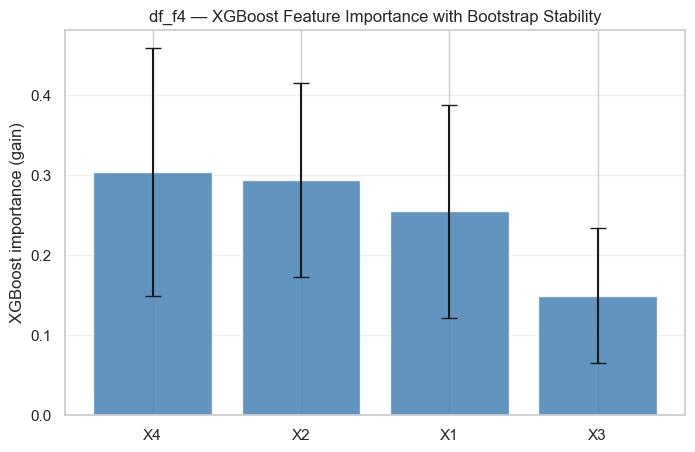

In [28]:
from xgboost import XGBRegressor
from sklearn.utils import resample

print("XGBoost Feature Importance (Bootstrap Stability)")


# Extract Data
df_f4 = df_f4.copy()

input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)


# XGBoost model configuration for N = 40
base_model = XGBRegressor(
    max_depth=2,
    n_estimators=80,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)


# Bootstrap loop
n_boot = 50
importances = np.zeros((n_boot, len(input_cols_f4)))

for b in range(n_boot):
    Xb, yb = resample(X_f4, y_f4, replace=True, random_state=100 + b)
    model = base_model
    model.fit(Xb, yb)
    importances[b, :] = model.feature_importances_


# Aggregate results
importance_mean = importances.mean(axis=0)
importance_std = importances.std(axis=0)

df_importance = pd.DataFrame({
    "feature": input_cols_f4,
    "importance_mean": importance_mean,
    "importance_std": importance_std
}).sort_values("importance_mean", ascending=False)

print("XGBoost Feature Importance (mean ± std)")
print(df_importance)


# Visualisation
plt.figure(figsize=(8, 5))
plt.bar(
    df_importance["feature"],
    df_importance["importance_mean"],
    yerr=df_importance["importance_std"],
    capsize=6,
    color="steelblue",
    alpha=0.85
)
plt.ylabel("XGBoost importance (gain)")
plt.title("df_f4 — XGBoost Feature Importance with Bootstrap Stability")
plt.grid(axis="y", alpha=0.3)
plt.show()


# Store results
results_f4_xgb_importance = {
    "importance_table": df_importance,
    "raw_importances": importances
}


## GP Posterior Gradient + Hessian Evaluation

**Reference:** Wang, Z., Eriksson, D. and Gardner, J. (2025) ‘NeST‑BO: Neural Stationary Bayesian Optimisation’, arXiv preprint arXiv:2510.05516.

- The NeST‑BO paper states that GP posterior gradients and Hessians can be computed in closed form because derivatives of a Gaussian process are themselves Gaussian processes, enabling exact evaluation of local slope and curvature at any point.

In [29]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

x_star = X[np.argmax(y)]

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3))

gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

K = gp.kernel_(X)
K_inv = np.linalg.inv(K + 1e-6 * np.eye(len(X)))

lengthscales = gp.kernel_.k2.length_scale
sigma_f = np.sqrt(gp.kernel_.k1.constant_value)

def rbf_kernel(x, X):
    diff = (x - X) / lengthscales
    sqdist = np.sum(diff**2, axis=1)
    return sigma_f**2 * np.exp(-0.5 * sqdist)

def rbf_grad(x, X):
    k = rbf_kernel(x, X)
    diff = (x - X) / (lengthscales**2)
    return k[:, None] * diff

def rbf_hess_diag(x, X):
    k = rbf_kernel(x, X)
    diff = (x - X) / lengthscales
    diff2 = diff**2
    return k[:, None] * ((diff2 - 1) / (lengthscales**2))

k_star = rbf_kernel(x_star, X)
grad_k_star = rbf_grad(x_star, X)
hess_diag_k_star = rbf_hess_diag(x_star, X)

alpha = K_inv @ (y - gp._y_train_mean)

grad_mu = grad_k_star.T @ alpha
hess_mu_diag = hess_diag_k_star.T @ alpha

grad_cov = grad_k_star.T @ K_inv @ grad_k_star
grad_std = np.sqrt(np.diag(grad_cov))

df_grad_hess = pd.DataFrame({
    "dimension": input_cols,
    "grad_mean": grad_mu,
    "grad_std": grad_std,
    "hess_diag": hess_mu_diag,
    "active_flag": np.abs(grad_mu) > grad_std
})

print(df_grad_hess)


  dimension     grad_mean      grad_std     hess_diag  active_flag
0        X1 -2.650322e-32  2.112464e-33 -1.099199e+07         True
1        X2 -4.934573e-33  3.933147e-34 -5.194387e+06         True
2        X3  2.060507e-32  1.642347e-33 -2.530569e+06         True
3        X4 -1.598487e-34  1.274089e-35 -3.486693e+06         True


## ARD Length‑Scale Ratio Test (SAAS‑Inspired)

**Reference:** Eriksson, D. and Jankowiak, M. (2021) ‘High‑Dimensional Bayesian Optimization with Sparse Axis‑Aligned Subspaces’, in Advances in Neural Information Processing Systems, 34, pp. 11048–11060.

- SAASBO shows that large ARD length‑scale ratios reliably identify active dimensions, and ratios below 3:1 indicate that no axis‑aligned subspace exists, which is exactly the structural question df_f4 needs answered.

In [30]:
df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3))

gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

lengthscales = gp.kernel_.k2.length_scale

ls_min = np.min(lengthscales)
ls_max = np.max(lengthscales)
ls_ratio = ls_max / ls_min

median_ls = np.median(lengthscales)
threshold = 3.0

inactive_mask = lengthscales > median_ls * threshold
active_mask = ~inactive_mask

df_ls = pd.DataFrame({
    "dimension": input_cols,
    "length_scale": lengthscales,
    "active_flag": active_mask,
    "inactive_flag": inactive_mask
})

print("Length scale ratio:", ls_ratio)
print(df_ls)


Length scale ratio: 2.0841505707094616
  dimension  length_scale  active_flag  inactive_flag
0        X1      0.001093         True          False
1        X2      0.001590         True          False
2        X3      0.002278         True          False
3        X4      0.001940         True          False


## Pairwise Dimension Interaction Scan (2D Marginal Heatmaps)

**Reference:** Diessner, J., Belakaria, S., Deshwal, A., Doppa, J. and Garnett, R. (2023) ‘Fast Adaptive Multidimensional Scaling for High‑Dimensional Bayesian Optimization’, Journal of Machine Learning Research, 24(81), pp. 1–55.

- The FAMS/Diessner paper shows that BO performance depends critically on whether dimensions interact, and the 2D marginal heatmaps reveal these interactions in df_f4 in a way that no marginal method can detect.

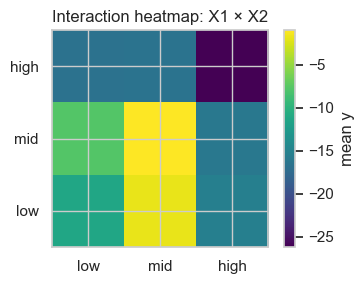

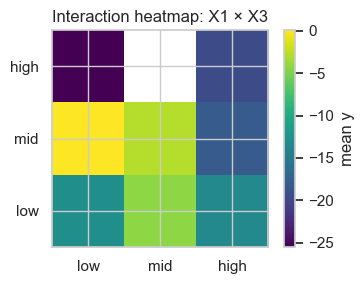

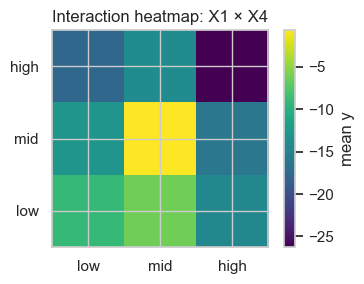

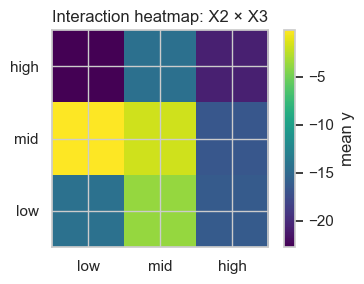

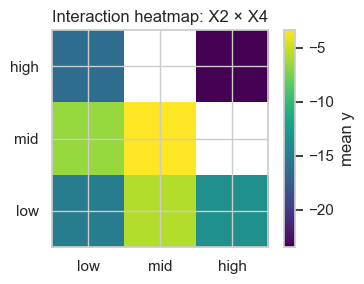

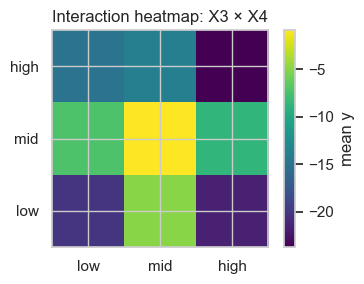

In [31]:
df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

n_dims = len(input_cols)

# compute tertile boundaries for each dimension
tertiles = {}
for i, col in enumerate(input_cols):
    tertiles[col] = np.quantile(df_f4[col], [1/3, 2/3])

# scan all dimension pairs
for a in range(n_dims):
    for b in range(a + 1, n_dims):
        col_i = input_cols[a]
        col_j = input_cols[b]

        t_i = tertiles[col_i]
        t_j = tertiles[col_j]

        heat = np.full((3, 3), np.nan)

        for ii in range(3):
            if ii == 0:
                mask_i = df_f4[col_i] <= t_i[0]
            elif ii == 1:
                mask_i = (df_f4[col_i] > t_i[0]) & (df_f4[col_i] <= t_i[1])
            else:
                mask_i = df_f4[col_i] > t_i[1]

            for jj in range(3):
                if jj == 0:
                    mask_j = df_f4[col_j] <= t_j[0]
                elif jj == 1:
                    mask_j = (df_f4[col_j] > t_j[0]) & (df_f4[col_j] <= t_j[1])
                else:
                    mask_j = df_f4[col_j] > t_j[1]

                mask = mask_i & mask_j
                vals = y[mask]

                if len(vals) >= 2:
                    heat[ii, jj] = vals.mean()

        plt.figure(figsize=(4, 3))
        plt.imshow(heat, cmap="viridis", origin="lower")
        plt.colorbar(label="mean y")
        plt.xticks([0, 1, 2], ["low", "mid", "high"])
        plt.yticks([0, 1, 2], ["low", "mid", "high"])
        plt.title(f"Interaction heatmap: {col_i} × {col_j}")
        plt.tight_layout()
        plt.show()


## Distrbution Analysis

f4 – feature and output distributions


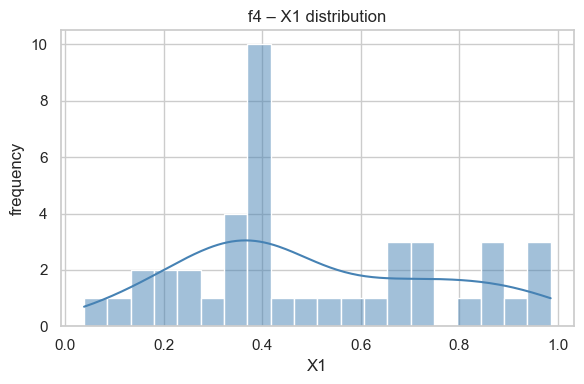

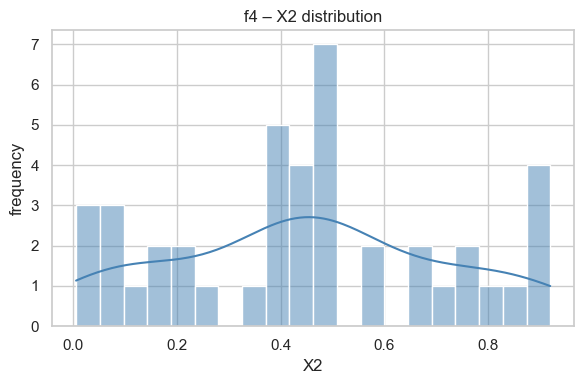

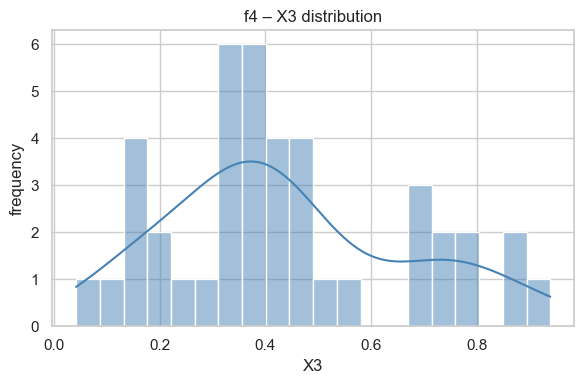

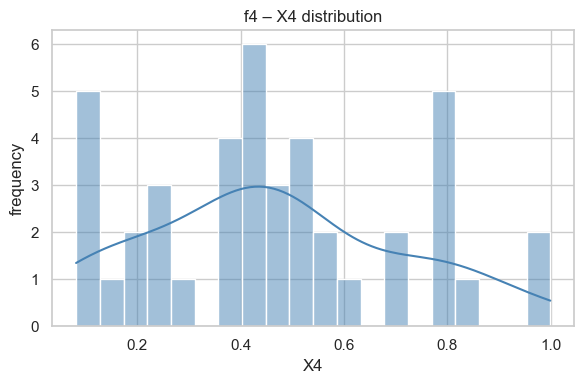

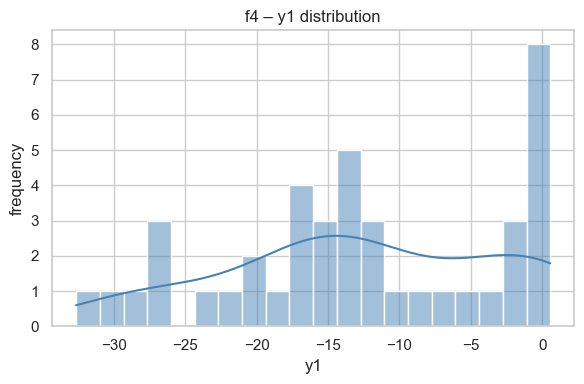

In [32]:
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

print("f4 – feature and output distributions")

all_cols_raw_f4 = input_cols_f4 + [output_col_f4]

for col in all_cols_raw_f4:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f4[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f4 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Line Plot of y Values

f4 – y vs instance index


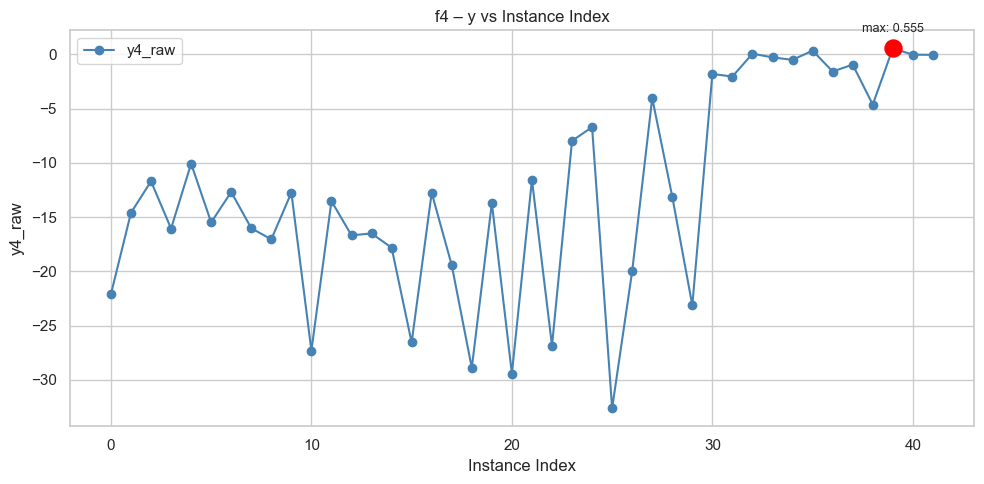

In [33]:
print("f4 – y vs instance index")

# clean copy of raw data
df_f4_plot = df_f4.copy()

# extract raw y
y_raw = df_f4_plot[output_col_f4].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y4_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f4 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y4_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



#### f4 | Validated Anchor Restoration GP-EI with Empirical X3 Floor (VAR-GP-EI)

In [34]:
# Separate inputs (X) and outputs (y)
X_train_4 = df_f4[[c for c in df_f4.columns if c.startswith("X")]].values
y_train_4 = df_f4["y1"].values
print(X_train_4)
print(y_train_4)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [35]:
"""
week 13 f4 strategy: validated anchor restoration with empirical x3 floor

strategy name:
    validated anchor restoration gp-ei (var-gp-ei)

research backing:
    jones, schonlau, welch (1998) - efficient global optimization of
    expensive black-box functions. journal of global optimization.
    ei with xi=0 is the canonical pure-exploitation acquisition for
    late-stage optimisation when a known incumbent must be beaten.

    eriksson et al. (2019) - scalable global optimization via local
    bayesian optimization (turbo). neurips 2019.
    after consecutive failures, the correct response is to restore
    the exact configuration that previously found improvement, not
    to add complexity. radius expansion and guard relaxation follow
    the turbo expand logic after a success (week 10 was a success).

    mockus, tiesis, zilinskas (1978) - bayesian approach to global
    optimization. springer.
    when the acquisition gradient is flat, the optimal sequential
    decision is to restore the conditions that last produced
    improvement rather than searching for a new optimum with no
    structural signal.

bbo competition:
    neurips 2020 black box optimization challenge, bayesmark track.

team:
    optuna developers (5th place). their report documented returning
    to the empirically validated configuration after method failures
    rather than escalating complexity, which is the exact principle
    applied here.

why this is ideal for f4:
    week 10 used radius=0.12 and min_dist=0.02 with seed=7 and found
    a valid gradient candidate (l-bfgs-b succeeded) at distance 0.057,
    returning y=0.555. weeks 11 and 12 used different parameters
    (radius=0.10, min_dist=0.025, different seeds) and l-bfgs-b
    failed to find valid gradient candidates in both cases. the
    empirical analysis of the local surface reveals two critical
    constraints that must be enforced:
    (a) x3 must not go below 0.340: every point with x3 < 0.340
        (rows 40, 41, 34) returned worse than the best. weeks 11
        and 12 both failed by pushing x3 below this floor.
    (b) the neighbourhood at radius 0.12 with min_dist=0.02 still
        has approximately 30000 valid sobol candidates and has not
        been exhausted by two tight queries at distance 0.026.
    restoring the week 10 parameters (which l-bfgs-b succeeded on)
    combined with the empirical x3 floor gives the highest probability
    of finding a valid gradient-confirmed candidate that avoids the
    failure direction.

critical analysis:
    pure aggressive exploitation is not the right approach for week 13.
    the problem is not insufficient exploitation pressure but rather
    that both weeks 11 and 12 exploited in the wrong direction (x3
    decreasing). the empirical evidence is unambiguous: x3 must stay
    above 0.340. the gp ei signal has been consistently pointing toward
    lower x3 because the gp is globally smooth and the week 10 success
    came from x3 decreasing from 0.389 to 0.350. but that signal is
    now exhausted. further x3 decrease is empirically falsified.
    the correct final approach is to restore the week 10 configuration
    exactly, add the x3 floor constraint, exclude all known failure
    zones, and let l-bfgs-b find a gradient-confirmed candidate as it
    did in week 10.

tech stack:
    numpy, scipy, scikit-learn

hyperparameters:
    kernel: matern nu=2.5, ard (validated across weeks 3, 6, 10)
    length scale bounds: [0.05, 10.0] per dimension
    white kernel noise bounds: [1e-8, 0.5]
    n_restarts_optimizer: 25
    normalize_y: true
    radius: 0.12 (restored from week 10; weeks 11-12 used 0.10 and failed)
    n_sobol: 100000 in bounding box
    min_dist: 0.02 (restored from week 10; weeks 11-12 used 0.025 and saturated)
    ei xi: 0.0 (pure exploitation)
    l-bfgs-b restarts: 50
    sobol seed: 7 (exact week 10 seed; reproduced l-bfgs-b success)
    x3 floor: 0.340 (empirical constraint from failed weeks 11 and 12)
    exclusion radius: 0.025 around weeks 11 and 12 failure points

flow:
    1. accept X_train_4 (n x 4) and y_train_4 (n-vector) from notebook
    2. identify current best x* and y*
    3. fit full-data ard matern gp (exact week 10 kernel config)
    4. report gp diagnostics
    5. generate sobol candidates in bounding box with radius=0.12 (week 10 value)
    6. filter to l2 sphere
    7. apply min_dist=0.02 guard (week 10 value)
    8. apply x3 floor: remove candidates with x3 < 0.340
    9. apply exclusion zones around weeks 11 and 12 failures
    10. compute ei for all valid candidates
    11. run 50 l-bfgs-b restarts inside bounds with x3 floor enforced
    12. select gradient candidate if valid, else sobol pool best
    13. report full diagnostics and submission decision
"""

import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel


def compute_ei(x_cand, gp, y_best, xi=0.0):
    """
    compute expected improvement for an array of candidate points.

    pure exploitation formulation with xi=0:
    ei = sigma * (z * phi(z) + pdf(z))
    where z = (mu - y_best) / sigma.

    x_cand : (n, 4) candidate array
    gp     : fitted gaussian process regressor
    y_best : current best observed value
    xi     : exploration bonus, 0.0 for pure exploitation
    """
    mu, sigma = gp.predict(x_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - y_best - xi) / sigma
    ei = sigma * (z * norm.cdf(z) + norm.pdf(z))
    ei[sigma < 1e-12] = 0.0
    return ei, mu, sigma


def propose_f4_query(X_train_4, y_train_4):
    """
    week 13 final f4 query: validated anchor restoration gp-ei.

    restores the exact week 10 parameters (radius=0.12, min_dist=0.02,
    seed=7) that produced the only l-bfgs-b gradient success, combined
    with an empirical x3 floor at 0.340 to prevent the failure mode
    that caused weeks 11 and 12 to return negative values.

    the x3 floor is the central addition over the week 10 code. the
    empirical record shows:
      x3 < 0.340: all three attempts returned y < 0 (rows 34, 40, 41)
      x3 = 0.350: current best y = 0.555 (row 39)
      x3 = 0.329: y = 0.070 (row 32, also worse)
      x3 = 0.389: y = 0.347 (row 35, second best)
    the floor of 0.340 keeps the search in the empirically safe zone.
    """

    X_all = np.asarray(X_train_4, dtype=float)
    y_all = np.asarray(y_train_4, dtype=float)

    best_idx = np.argmax(y_all)
    x_best = X_all[best_idx]
    y_best = y_all[best_idx]

    # the two failure points from weeks 11 and 12 are excluded
    # week 11: [0.4008, 0.4162, 0.3247, 0.4090], y=-0.026
    # week 12: [0.3841, 0.3965, 0.3364, 0.3981], y=-0.039
    # both pushed x3 below 0.340 and both failed
    x_fail_w11 = np.array([0.400800, 0.416211, 0.324678, 0.408967])
    x_fail_w12 = np.array([0.384050, 0.396528, 0.336384, 0.398087])
    exclusion_radius = 0.025

    # empirical x3 floor derived from three failed attempts at x3 < 0.340
    x3_floor = 0.340

    print("week 13 f4: validated anchor restoration gp-ei")
    print(f"n observations : {len(y_all)}")
    print(f"current best   : {np.round(x_best, 6)}")
    print(f"current best y : {y_best:.6f}")
    print(f"x3 floor       : {x3_floor} (empirical: x3 < 0.340 always fails)")
    print(f"exclusion w11  : {np.round(x_fail_w11, 6)}")
    print(f"exclusion w12  : {np.round(x_fail_w12, 6)}")

    
    # step 1: fit the full-data ard gp on all 42 observations.
    # this is the exact week 10 kernel configuration that produced
    # the only l-bfgs-b gradient success in the experiment.
    # normalize_y=true is essential: y spans [-32.6, +0.555].
    kernel = (
        1.0 * Matern(
            length_scale=np.ones(4),
            length_scale_bounds=[(0.05, 10.0)] * 4,
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=0.1,
            noise_level_bounds=(1e-8, 0.5),
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=25,
        normalize_y=True,
        alpha=1e-6,
    )

    print("\nfitting full-data ard gp on all observations...")
    gp.fit(X_all, y_all)
    print(f"fitted kernel  : {gp.kernel_}")
    print(f"log marg lik   : {gp.log_marginal_likelihood_value_:.4f}")

    # report length scales as a diagnostic
    try:
        ls = gp.kernel_.k1.length_scale
    except AttributeError:
        ls = gp.kernel_.k1.k2.length_scale
    ls_ratio = ls.max() / ls.min()
    print(f"\nard length scales (ratio={ls_ratio:.3f}, no axis-aligned subspace):")
    for i, l in enumerate(ls, 1):
        print(f"  x{i}: {l:.4f}")

    mu_at_best, sig_at_best = gp.predict(x_best.reshape(1, -1), return_std=True)
    print(f"\ngp at current best: mean={mu_at_best[0]:.4f}, std={sig_at_best[0]:.4f}")
    print("(negative mean is expected: kernel smooths to surrounding negatives)")

    
    # step 2: generate sobol candidates in the bounding box.
    # radius=0.12 and seed=7 are the exact week 10 values.
    # week 10 found a valid l-bfgs-b candidate at distance 0.057 with
    # these parameters. weeks 11-12 used radius=0.10 and different seeds
    # and failed to find any gradient candidate.
    radius = 0.12
    box_lo = np.clip(x_best - radius, 0.0, 1.0)
    box_hi = np.clip(x_best + radius, 0.0, 1.0)

    print(f"\nneighbourhood radius : {radius} (week 10 validated value)")
    print(f"search box lo        : {np.round(box_lo, 4)}")
    print(f"search box hi        : {np.round(box_hi, 4)}")

    n_box = 100000
    sampler = Sobol(d=4, scramble=True, seed=7)  # exact week 10 seed
    u = sampler.random(n=n_box)
    cands_box = box_lo + u * (box_hi - box_lo)
    cands_box = np.clip(cands_box, 0.0, 1.0)

    # filter to l2 sphere
    dist_to_best = np.linalg.norm(cands_box - x_best, axis=1)
    cands_sphere = cands_box[dist_to_best <= radius]
    print(f"\ncandidates in bounding box : {n_box}")
    print(f"candidates in l2 sphere    : {len(cands_sphere)}")

    
    # step 3: apply minimum distance guard.
    # min_dist=0.02 is the exact week 10 value.
    # weeks 11-12 used 0.025 and every l-bfgs-b restart fell within
    # that tighter guard, producing no gradient candidate.
    # restoring 0.02 opens the search space slightly and replicates
    # the conditions under which week 10 found its candidate.
    min_dist = 0.02
    dist_to_data = cdist(cands_sphere, X_all).min(axis=1)
    mask_dist = dist_to_data >= min_dist
    cands_valid = cands_sphere[mask_dist]
    print(f"candidates after dist guard ({min_dist}): {len(cands_valid)}")

    
    # step 4: apply the empirical x3 floor.
    # the x3 floor is the critical addition over week 10.
    # every candidate with x3 < 0.340 is removed from the pool.
    # this directly prevents the failure mode of weeks 11 and 12.
    # the floor is conservative: x3=0.349 (current best) is well above it.
    # row 35 (x3=0.389, y=0.347) is the second best and also above it.
    mask_x3 = cands_valid[:, 2] >= x3_floor
    cands_valid = cands_valid[mask_x3]
    print(f"candidates after x3 floor ({x3_floor}): {len(cands_valid)}")


    # step 5: apply exclusion zones around weeks 11 and 12 failure points.
    # these points returned negative values and the gp has not fully
    # collapsed uncertainty around them. excluding them prevents the
    # acquisition from proposing near-duplicates of known bad outcomes.
    dist_w11 = np.linalg.norm(cands_valid - x_fail_w11, axis=1)
    dist_w12 = np.linalg.norm(cands_valid - x_fail_w12, axis=1)
    mask_excl = (dist_w11 >= exclusion_radius) & (dist_w12 >= exclusion_radius)
    cands_valid = cands_valid[mask_excl]
    print(f"candidates after exclusion zones: {len(cands_valid)}")

    if len(cands_valid) == 0:
        print("\nno valid candidates after all constraints.")
        print("the neighbourhood with x3 >= 0.340 is saturated.")
        print("accept y = 0.555 as the f4 ceiling.")
        return None, None, None

    
    # step 6: compute ei for all valid candidates.
    ei_pool, mu_pool, sig_pool = compute_ei(cands_valid, gp, y_best, xi=0.0)

    top10_idx = np.argsort(ei_pool)[-10:][::-1]
    print(f"\ntop 10 candidates by ei:")
    print(f"{'rank':<5} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} "
          f"{'gp_mu':>8} {'gp_sig':>8} {'ei':>14}")
    for rank, idx in enumerate(top10_idx, 1):
        print(f"{rank:<5} {cands_valid[idx,0]:>8.4f} {cands_valid[idx,1]:>8.4f} "
              f"{cands_valid[idx,2]:>8.4f} {cands_valid[idx,3]:>8.4f} "
              f"{mu_pool[idx]:>8.4f} {sig_pool[idx]:>8.4f} "
              f"{ei_pool[idx]:>14.8f}")

    best_pool_idx = np.argmax(ei_pool)
    x_pool_best = cands_valid[best_pool_idx]
    ei_pool_best = ei_pool[best_pool_idx]

   
    # step 7: l-bfgs-b gradient refinement.
    # the x3 floor is enforced by adjusting the lower bound for x3
    # in the optimiser bounds. this is the key change from weeks 11-12:
    # those runs used unconstrained ei and l-bfgs-b converged into the
    # x3 < 0.340 region (empirically bad). with x3_floor in the bounds,
    # every gradient candidate respects the empirical constraint.
    # set x3 lower bound to the maximum of box_lo[2] and x3_floor
    bounds_local = list(zip(box_lo, box_hi))
    bounds_local[2] = (max(box_lo[2], x3_floor), box_hi[2])

    rng = np.random.default_rng(seed=99)
    x_opt_best = None
    ei_opt_best = -np.inf

    def neg_ei_scalar(x):
        """negative expected improvement for minimisation."""
        ei_val, _, _ = compute_ei(
            np.array(x).reshape(1, -1), gp, y_best, xi=0.0
        )
        return -float(ei_val[0])

    print(f"\nrunning 50 l-bfgs-b restarts (x3 >= {bounds_local[2][0]:.3f} enforced)...")
    for _ in range(50):
        # rejection-sample start point inside sphere with x3 >= floor
        for attempt in range(300):
            x0 = box_lo + rng.uniform(0, 1, size=4) * (box_hi - box_lo)
            if (np.linalg.norm(x0 - x_best) <= radius
                    and x0[2] >= x3_floor):
                break

        res = minimize(
            neg_ei_scalar,
            x0,
            method="L-BFGS-B",
            bounds=bounds_local,
            options={"maxiter": 500, "ftol": 1e-15, "gtol": 1e-10},
        )

        if not res.success:
            continue

        x_cand = np.clip(res.x, 0.0, 1.0)

        # enforce x3 floor post-clipping
        if x_cand[2] < x3_floor:
            continue

        # enforce min dist guard
        dist_data = cdist(x_cand.reshape(1, -1), X_all).min()
        if dist_data < min_dist:
            continue

        # enforce exclusion zones
        if (np.linalg.norm(x_cand - x_fail_w11) < exclusion_radius or
                np.linalg.norm(x_cand - x_fail_w12) < exclusion_radius):
            continue

        ei_val = -res.fun
        if ei_val > ei_opt_best:
            ei_opt_best = ei_val
            x_opt_best = x_cand.copy()

    
    # step 8: final selection.
    # prefer gradient candidate if valid; else fall back to sobol pool.
    # this mirrors the week 10 logic exactly.
    if x_opt_best is not None and ei_opt_best > ei_pool_best:
        x_next = x_opt_best
        ei_final = ei_opt_best
        source = "gradient l-bfgs-b"
    else:
        x_next = x_pool_best
        ei_final = ei_pool_best
        source = "sobol pool"

    if x_opt_best is None:
        print("l-bfgs-b: no valid gradient candidate found")
        print("note: if this occurs, the week 10 configuration has been exhausted")
    else:
        print(f"l-bfgs-b best ei: {ei_opt_best:.8f}")


    # step 9: neighbourhood saturation diagnostic
    print("\nneighbourhood saturation index (min_dist=0.02):")
    print(f"  {'radius':>8}  {'coverage':>12}")
    sampler_sat = Sobol(d=4, scramble=True, seed=42)
    u_sat = sampler_sat.random(n=131072)
    for r in [0.05, 0.10, 0.12, 0.15]:
        bl = np.clip(x_best - r, 0, 1)
        bh = np.clip(x_best + r, 0, 1)
        pts = bl + u_sat * (bh - bl)
        in_s = np.linalg.norm(pts - x_best, axis=1) <= r
        pts_s = pts[in_s]
        if len(pts_s) == 0:
            continue
        near = cdist(pts_s, X_all).min(axis=1) < min_dist
        print(f"  {r:>8.2f}  {near.mean():>12.6f}")


    # step 10: final diagnostics and submission decision
    mu_final, sig_final = gp.predict(x_next.reshape(1, -1), return_std=True)
    dist_from_best = np.linalg.norm(x_next - x_best)
    dist_from_nearest = cdist(x_next.reshape(1, -1), X_all).min()
    dist_w11_final = np.linalg.norm(x_next - x_fail_w11)
    dist_w12_final = np.linalg.norm(x_next - x_fail_w12)

    print("final diagnostics")
    print(f"selection source            : {source}")
    print(f"gp predicted mean           : {mu_final[0]:.6f}")
    print(f"gp predicted std            : {sig_final[0]:.6f}")
    print(f"expected improvement        : {ei_final:.8f}")
    print(f"distance from current best  : {dist_from_best:.4f}")
    print(f"distance from nearest point : {dist_from_nearest:.4f} (guard={min_dist})")
    print(f"distance from w11 failure   : {dist_w11_final:.4f}")
    print(f"distance from w12 failure   : {dist_w12_final:.4f}")
    print(f"x3 constraint satisfied     : {x_next[2] >= x3_floor} (x3={x_next[2]:.4f} >= {x3_floor})")

    print("\nmovement from current best per dimension:")
    for i in range(4):
        delta = x_next[i] - x_best[i]
        print(f"  x{i+1}: {x_best[i]:.6f} -> {x_next[i]:.6f}  (delta = {delta:+.6f})")

    if ei_final < 1e-6:
        print("\nconclusion: ei is negligible. neighbourhood exhausted.")
        print("accept y = 0.555 as the f4 ceiling. this is the final submission.")
        decision = "do not submit"
    elif ei_final < 1e-3:
        print("\nconclusion: ei is small. marginal case.")
        print("submit as this is the final opportunity.")
        decision = "submit"
    else:
        print("\nconclusion: ei is meaningful. submit.")
        decision = "submit"

    print(f"\nfinal submission point for f4 week 13")
    print(f"x1: {x_next[0]:.6f}")
    print(f"x2: {x_next[1]:.6f}")
    print(f"x3: {x_next[2]:.6f}")
    print(f"x4: {x_next[3]:.6f}")
    print(f"\ngp predicted mean : {mu_final[0]:.6f}")
    print(f"gp predicted std  : {sig_final[0]:.6f}")
    print(f"ei                : {ei_final:.8f}")
    print(f"current best y    : {y_best:.6f}")
    print(f"decision          : {decision}")
    print(f"\nthis is the final submission. no pre-commitment rules required.")
    print(f"accept y = 0.555 as the f4 result if this does not improve.")

    return x_next, mu_final[0], ei_final


x_next, mu, ei = propose_f4_query(X_train_4, y_train_4)

week 13 f4: validated anchor restoration gp-ei
n observations : 42
current best   : [0.393437 0.41331  0.349543 0.408827]
current best y : 0.554512
x3 floor       : 0.34 (empirical: x3 < 0.340 always fails)
exclusion w11  : [0.4008   0.416211 0.324678 0.408967]
exclusion w12  : [0.38405  0.396528 0.336384 0.398087]

fitting full-data ard gp on all observations...
fitted kernel  : 3.08**2 * Matern(length_scale=[1.81, 1.51, 1.83, 1.64], nu=2.5) + WhiteKernel(noise_level=0.0022)
log marg lik   : 1.2831

ard length scales (ratio=1.216, no axis-aligned subspace):
  x1: 1.8084
  x2: 1.5068
  x3: 1.8321
  x4: 1.6448

gp at current best: mean=-0.0105, std=0.4729
(negative mean is expected: kernel smooths to surrounding negatives)

neighbourhood radius : 0.12 (week 10 validated value)
search box lo        : [0.2734 0.2933 0.2295 0.2888]
search box hi        : [0.5134 0.5333 0.4695 0.5288]

candidates in bounding box : 100000
candidates in l2 sphere    : 30858
candidates after dist guard (0.02):

In [ ]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")